# Novelty-Driven Mean Reversion
### An NLP-Powered Event-Driven Strategy
**Signal Logic:** Identify firm-specific semantic anomalies in earnings call transcripts — sentences that are linguistically novel relative to a firm's historical baseline AND financially salient — then short the market overreaction.

**Pipeline:**
1. **Baseline Build** — Per-firm TF-IDF vocabulary profile from historical transcripts
2. **Semantic Anomaly Detection** — Sentence embeddings (`all-MiniLM-L6-v2`) + cosine distance from historical centroid
3. **Intent Verification** — Salience dictionary scoring as a precision filter (business catalyst vs. noise)
4. **Macro Adjustment** — Cross-sectional penalty: discount topics appearing across ≥40% of firms simultaneously

> **Note on embedding model choice:** FinBERT is a *sentiment classifier* — its embeddings encode positivity/negativity, not semantic content. For novelty detection we need a *sentence encoder* that preserves meaning. `all-MiniLM-L6-v2` is purpose-built for semantic similarity and cosine distance tasks.


## 0. Environment & Imports

In [5]:
# Install dependencies if needed
# !pip install sentence-transformers scikit-learn vroom pandas numpy

import warnings
warnings.filterwarnings("ignore")

import sys, os, re, json, pickle
from pathlib import Path
from collections import defaultdict

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Sentence embeddings — semantic encoder, NOT FinBERT (sentiment classifier)
from sentence_transformers import SentenceTransformer

# Salience dictionary — intent verification / topic classification
# Place salience_dictionary.py in the same directory as this notebook
sys.path.insert(0, str(Path(".").resolve()))
from salience_dictionary import score_sentence, SALIENCE_DICT

print("All imports OK")
print(f"Salience clusters: {len(SALIENCE_DICT)}")


All imports OK
Salience clusters: 26


## 1. Data Load

Input file: **`analytical_ml_finance/aggregated_all_years_with_event.csv`** (or the same filename in the notebook working directory). Only the columns in `USE_COLS` are loaded; extra event fields in the CSV stay on disk unless you add them to `USE_COLS`.

In [52]:


os.path()

TypeError: 'module' object is not callable

In [ ]:
import vroom  # fast CSV reader for large files

DATA_PATH = Path.home() / "Downloads" / "Raw Transcripts" / "aggregated_all_years.csv"
assert DATA_PATH.exists(), f"Data not found at {DATA_PATH}"

# Load — only columns we need (avoids reading 10GB into memory unnecessarily)
USE_COLS = [
    "transcriptid", "ticker", "companyname",
    "mostimportantdateutc", "full_transcript_text",
    "close_to_open_return", "close_price_call_day",
    "permno"
]

print("Loading data...")
raw = pd.read_csv(str(DATA_PATH), usecols=USE_COLS)
print(f"Raw shape: {raw.shape}")

# Derive quarter + fiscal year
raw["quarter"] = pd.to_datetime(
    raw["mostimportantdateutc"], errors="coerce"
).dt.to_period("Q")
raw["fiscal_year"] = raw["quarter"].dt.year
raw["quarter_str"]  = raw["quarter"].astype(str)   # e.g. "2022Q3"

# Drop rows without text or return data
raw = raw.dropna(subset=["full_transcript_text", "quarter"])
raw = raw[raw["full_transcript_text"].str.len() > 200]
print(f"After cleaning: {raw.shape}")


AttributeError: 'str' object has no attribute 'exists'

In [7]:
# Top-50 S&P 500 by index weight — heavy NLP scope
import yfinance as yf          # or use a hardcoded list if offline
try:
    import pandas_datareader as pdr
    sp500 = pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")[0]
    top50_tickers = sp500["Symbol"].head(50).tolist()
except Exception:
    # Fallback hardcoded top-50 as of 2024 (by weight)
    top50_tickers = [
        "AAPL","MSFT","NVDA","AMZN","META","GOOGL","GOOG","BRK-B","LLY","AVGO",
        "JPM","TSLA","UNH","V","XOM","MA","JNJ","PG","HD","MRK","COST","ABBV",
        "BAC","CRM","CVX","WFC","AMD","NFLX","KO","PEP","ORCL","TMO","ACN","LIN",
        "MCD","ABT","PM","GE","IBM","QCOM","DHR","AMGN","CAT","GS","INTC","ISRG",
        "SPGI","VZ","BLK","SCHW"
    ]

df = raw[raw["ticker"].isin(top50_tickers)].copy()
df = df.sort_values(["ticker", "quarter"]).reset_index(drop=True)

print(f"Top-50 corpus: {df.shape[0]:,} transcripts, {df['ticker'].nunique()} firms")
print(f"Date range: {df['quarter'].min()} → {df['quarter'].max()}")


Top-50 corpus: 2,650 transcripts, 43 firms
Date range: 2006Q1 → 2026Q1


## 2. Step 1 — Per-Firm Historical Baseline (TF-IDF)

Build a TF-IDF vocabulary profile for each firm using all transcripts *before* a given quarter. This defines what is **normal** for that firm linguistically.

The rolling approach means: for each firm-quarter observation, the baseline is everything the firm has said in prior quarters. We store top-N terms per firm-quarter as the baseline fingerprint.


In [8]:
def clean_text(txt: str) -> str:
    """Strip operator boilerplate and safe-harbour preambles."""
    txt = re.sub(r"\[Operator Instructions\]", "", txt, flags=re.I)
    txt = re.sub(r"(?i)forward.looking statements.{0,200}filings\.", "", txt)
    txt = re.sub(r"\s+", " ", txt)
    return txt.strip()

def split_sentences(txt: str) -> list[str]:
    """Rough sentence splitter."""
    sents = re.split(r"(?<=[.!?])\s+(?=[A-Z\"'(\[])", txt)
    return [s.strip() for s in sents if len(s.strip()) > 20]


In [9]:
# Build rolling per-firm TF-IDF baselines
# For each (ticker, quarter), fit TF-IDF on ALL prior quarters of that firm.

print("Building per-firm rolling TF-IDF baselines...")

BASELINE_CACHE = Path("./novelty_baselines.pkl")

if BASELINE_CACHE.exists():
    with open(BASELINE_CACHE, "rb") as f:
        firm_baselines = pickle.load(f)
    print(f"Loaded cached baselines: {len(firm_baselines)} firm-quarter pairs")
else:
    firm_baselines = {}   # key: (ticker, quarter_str) → TfidfVectorizer fitted on prior docs

    for ticker, grp in df.groupby("ticker"):
        quarters = sorted(grp["quarter_str"].unique())

        # Need at least 2 quarters of history before we can compute novelty
        for i, q in enumerate(quarters):
            if i < 2:
                continue   # skip first 2 quarters — not enough history

            prior_qs  = quarters[:i]
            prior_txt = grp[grp["quarter_str"].isin(prior_qs)]["full_transcript_text"].tolist()
            prior_txt = [clean_text(t) for t in prior_txt]

            if len(prior_txt) == 0:
                continue

            vec = TfidfVectorizer(
                max_features   = 3000,
                ngram_range    = (1, 2),
                min_df         = 1,
                stop_words     = "english",
                sublinear_tf   = True,
            )
            try:
                vec.fit(prior_txt)
                firm_baselines[(ticker, q)] = {
                    "vectorizer": vec,
                    "n_docs"    : len(prior_txt),
                    "vocab_size": len(vec.vocabulary_),
                }
            except Exception as e:
                pass

    with open(BASELINE_CACHE, "wb") as f:
        pickle.dump(firm_baselines, f)

    print(f"Built {len(firm_baselines)} firm-quarter baselines")


Building per-firm rolling TF-IDF baselines...
Built 2555 firm-quarter baselines


In [10]:
# Quick sanity check — inspect NVDA baseline
sample_key = [k for k in firm_baselines if k[0] == "NVDA"]
if sample_key:
    k = sorted(sample_key)[-1]
    bl = firm_baselines[k]
    print(f"NVDA baseline at {k[1]}:")
    print(f"  Trained on {bl['n_docs']} prior transcripts")
    print(f"  Vocabulary size: {bl['vocab_size']:,} terms")
    top_terms = sorted(bl['vectorizer'].vocabulary_.items(), key=lambda x: x[1], reverse=True)[:20]
    print(f"  Sample vocab: {[t for t,_ in top_terms[:20]]}")


NVDA baseline at 2025Q4:
  Trained on 76 prior transcripts
  Vocabulary size: 3,000 terms
  Sample vocab: ['yields', 'yield', 'yeung', 'yesterday', 'yes think', 'yes thanks', 'yes', 'years ve', 'years ago', 'years', 'year yes', 'year year', 'year think', 'year strong', 'year sequentially', 'year revenue', 'year question', 'year ll', 'year just', 'year growth']


## 3. Step 2 — Semantic Anomaly Detection

For each firm-quarter, embed the **new** transcript sentences using `all-MiniLM-L6-v2` and compare them against the **historical sentence centroid** for that firm.

**Novelty Score** = 1 − cosine_similarity(new_sentence, historical_centroid)

A score near 1.0 means the sentence is semantically far from anything the firm has said historically. A score near 0 means it's the usual language.

> Why `all-MiniLM-L6-v2`? It is a purpose-built **semantic sentence encoder** trained on paraphrase and NLI tasks — its embedding space preserves *meaning*, making cosine distance a valid measure of semantic novelty. FinBERT's embedding space encodes *sentiment polarity*, not meaning — cosine distance between FinBERT embeddings would measure sentiment distance, not novelty.


In [11]:
# Load sentence encoder — once, shared across all calls
print("Loading sentence encoder...")
ENCODER = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded.")


Loading sentence encoder...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.


In [12]:
NOVELTY_CACHE = Path("./novelty_scores.pkl")

if NOVELTY_CACHE.exists():
    with open(NOVELTY_CACHE, "rb") as f:
        novelty_records = pickle.load(f)
    print(f"Loaded {len(novelty_records):,} cached novelty records")

else:
    novelty_records = []   # list of dicts: one row per sentence

    # For efficiency, embed historical sentences per firm ONCE (pooled across quarters)
    # then build centroid. For new quarter, embed its sentences and score.

    firm_historical_embeddings = {}   # ticker → np.array of shape (N, 384)

    # Process in chronological order per firm
    for ticker, grp in df.groupby("ticker"):
        grp = grp.sort_values("quarter")
        quarters = grp["quarter_str"].unique().tolist()
        quarters_sorted = sorted(quarters)

        for i, q in enumerate(quarters_sorted):
            if i < 2:
                # Accumulate historical embeddings without scoring
                hist_rows = grp[grp["quarter_str"] == q]
                for _, row in hist_rows.iterrows():
                    sents = split_sentences(clean_text(row["full_transcript_text"]))[:60]
                    if not sents:
                        continue
                    embs = ENCODER.encode(sents, batch_size=64,
                                          normalize_embeddings=True,
                                          show_progress_bar=False)
                    if ticker not in firm_historical_embeddings:
                        firm_historical_embeddings[ticker] = embs
                    else:
                        firm_historical_embeddings[ticker] = np.vstack(
                            [firm_historical_embeddings[ticker], embs]
                        )
                continue

            if ticker not in firm_historical_embeddings:
                continue

            # Compute historical centroid
            hist_embs  = firm_historical_embeddings[ticker]
            centroid   = hist_embs.mean(axis=0, keepdims=True)
            centroid   = normalize(centroid)   # unit-norm for cosine

            # Embed new quarter's sentences
            new_rows = grp[grp["quarter_str"] == q]
            for _, row in new_rows.iterrows():
                sents = split_sentences(clean_text(row["full_transcript_text"]))[:80]
                if not sents:
                    continue

                new_embs = ENCODER.encode(sents, batch_size=64,
                                           normalize_embeddings=True,
                                           show_progress_bar=False)

                # Cosine similarity to centroid (already unit-normed)
                sims     = cosine_similarity(new_embs, centroid).flatten()
                novelty  = 1.0 - sims   # high = novel

                for sent, nov, sim in zip(sents, novelty, sims):
                    novelty_records.append({
                        "ticker"            : ticker,
                        "quarter_str"       : q,
                        "fiscal_year"       : row["fiscal_year"],
                        "transcriptid"      : row["transcriptid"],
                        "close_to_open_return": row.get("close_to_open_return", np.nan),
                        "sentence"          : sent,
                        "novelty_score"     : float(nov),
                        "cosine_sim"        : float(sim),
                    })

                # Update rolling history with this quarter's embeddings
                firm_historical_embeddings[ticker] = np.vstack(
                    [hist_embs, new_embs]
                )

    with open(NOVELTY_CACHE, "wb") as f:
        pickle.dump(novelty_records, f)
    print(f"Computed {len(novelty_records):,} sentence novelty scores")

novelty_df = pd.DataFrame(novelty_records)
print(novelty_df.shape)
print(novelty_df[["ticker","quarter_str","novelty_score"]].describe())


Computed 205,120 sentence novelty scores
(205120, 8)
       novelty_score
count  205120.000000
mean        0.562533
std         0.131884
min         0.203736
25%         0.464526
50%         0.547526
75%         0.649615
max         1.077488


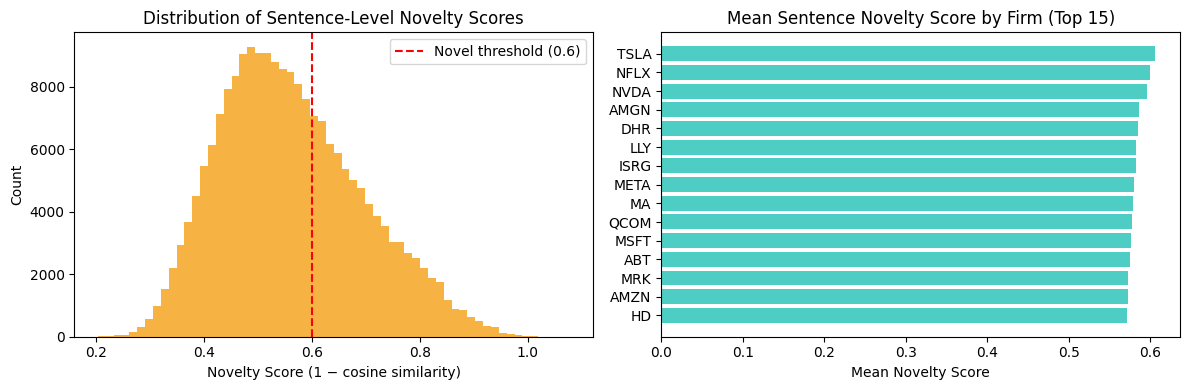

Saved novelty_distribution.png


In [13]:
# Distribution of novelty scores
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall distribution
axes[0].hist(novelty_df["novelty_score"], bins=60, color="#f5a623", edgecolor="none", alpha=0.85)
axes[0].set_title("Distribution of Sentence-Level Novelty Scores", fontsize=12)
axes[0].set_xlabel("Novelty Score (1 − cosine similarity)")
axes[0].set_ylabel("Count")
axes[0].axvline(0.6, color="red", linestyle="--", label="Novel threshold (0.6)")
axes[0].legend()

# By firm — top 15 most novel firms on average
firm_avg = (novelty_df.groupby("ticker")["novelty_score"]
            .mean()
            .sort_values(ascending=False)
            .head(15))
axes[1].barh(firm_avg.index[::-1], firm_avg.values[::-1], color="#4ecdc4")
axes[1].set_title("Mean Sentence Novelty Score by Firm (Top 15)", fontsize=12)
axes[1].set_xlabel("Mean Novelty Score")

plt.tight_layout()
plt.savefig("novelty_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved novelty_distribution.png")


## 4. Step 3 — Intent Verification via Salience Dictionary

A high novelty score confirms the firm is discussing something *new* — but not whether it matters financially. A novel sentence about litigation, regulatory disclosure, or a CEO aside would all score as novel.

We apply the **salience dictionary** to high-novelty sentences to verify that the novel content is a genuine business catalyst. The dictionary scores sentences across 26 financial clusters (guidance, earnings performance, revenue growth, new products, partnerships, etc.) — a strong proxy for the LLM binary intent filter described in the strategy paper.

**Signal criteria:**
- `novelty_score ≥ 0.60` — semantically distant from firm's historical baseline
- `salience_score ≥ 0.30` — meaningful financial content, not boilerplate


In [27]:
import requests, json

OLLAMA_URL   = "http://localhost:1212/api/generate"
OLLAMA_MODEL = "llama3.1"

NOVELTY_THRESHOLD  = 0.60
SALIENCE_THRESHOLD = 0.30
LLM_THRESHOLD      = 0.65   # stricter novelty cutoff before LLM call

LLM_INTENT_CACHE = Path("./llm_intent_cache.pkl")

def ollama_intent_check(sentence: str) -> bool:
    prompt = f"""You are a financial analyst reviewing a single sentence from an earnings call transcript.

Sentence: "{sentence}"

Does this sentence describe a DEFINITIVELY NEW revenue-generating project, new product launch, new customer contract, or new corporate partnership that this company has not previously disclosed?

Reply with ONLY one word: YES or NO."""
    try:
        resp = requests.post(
            OLLAMA_URL,
            json={
                "model"  : OLLAMA_MODEL,
                "prompt" : prompt,
                "stream" : False,
                "options": {"temperature": 0.0, "num_predict": 5}
            },
            timeout=30
        )
        return resp.json().get("response","").strip().upper().startswith("YES")
    except Exception as e:
        print(f"Ollama error: {e}")
        return False

# ── Load LLM cache ─────────────────────────────────────────────────────────────
if LLM_INTENT_CACHE.exists():
    with open(LLM_INTENT_CACHE, "rb") as f:
        intent_cache = pickle.load(f)
    print(f"Loaded {len(intent_cache):,} cached LLM results")
else:
    intent_cache = {}

# ── Step 1: salience filter on high-novelty sentences (same as before) ─────────
high_novelty = novelty_df[novelty_df["novelty_score"] >= NOVELTY_THRESHOLD].copy()
print(f"High-novelty sentences: {len(high_novelty):,}")

print("Scoring salience...")
results = []
for _, row in high_novelty.iterrows():
    score, breakdown = score_sentence(
        row["sentence"],
        year=int(row["fiscal_year"]) if pd.notna(row["fiscal_year"]) else 2020
    )
    top_cluster = max(breakdown, key=breakdown.get) if breakdown else None
    results.append({
        "salience_score"   : score,
        "top_cluster"      : top_cluster,
        "cluster_breakdown": json.dumps(breakdown),
    })

sal_df = pd.DataFrame(results, index=high_novelty.index)
signal_df = pd.concat([high_novelty.reset_index(drop=True),
                        sal_df.reset_index(drop=True)], axis=1)
signal_df = signal_df[signal_df["salience_score"] >= SALIENCE_THRESHOLD].copy()
print(f"After salience filter: {len(signal_df):,} sentences")

# ── Step 2: LLM intent filter on highest-confidence candidates only ─────────────
llm_candidates = signal_df[signal_df["novelty_score"] >= LLM_THRESHOLD].copy()
remaining      = signal_df[signal_df["novelty_score"] <  LLM_THRESHOLD].copy()

print(f"Sending {len(llm_candidates):,} high-confidence sentences to Ollama...")

llm_pass = []
for _, row in llm_candidates.iterrows():
    sent = row["sentence"]
    if sent not in intent_cache:
        intent_cache[sent] = ollama_intent_check(sent)
    llm_pass.append(intent_cache[sent])

llm_candidates["llm_intent_pass"] = llm_pass
remaining["llm_intent_pass"]      = True   # lower-novelty sentences skip LLM, pass through

# Save updated cache
with open(LLM_INTENT_CACHE, "wb") as f:
    pickle.dump(intent_cache, f)

# Recombine — drop LLM rejects from high-confidence set
signal_df = pd.concat([
    llm_candidates[llm_candidates["llm_intent_pass"] == True],
    remaining
], ignore_index=True)

print(f"After LLM intent filter: {len(signal_df):,} sentences")
print(f"LLM pass rate: {llm_candidates['llm_intent_pass'].mean():.1%}")


High-novelty sentences: 73,474
Scoring salience...
After salience filter: 20,952 sentences
Sending 11,954 high-confidence sentences to Ollama...
After LLM intent filter: 9,553 sentences
LLM pass rate: 4.6%


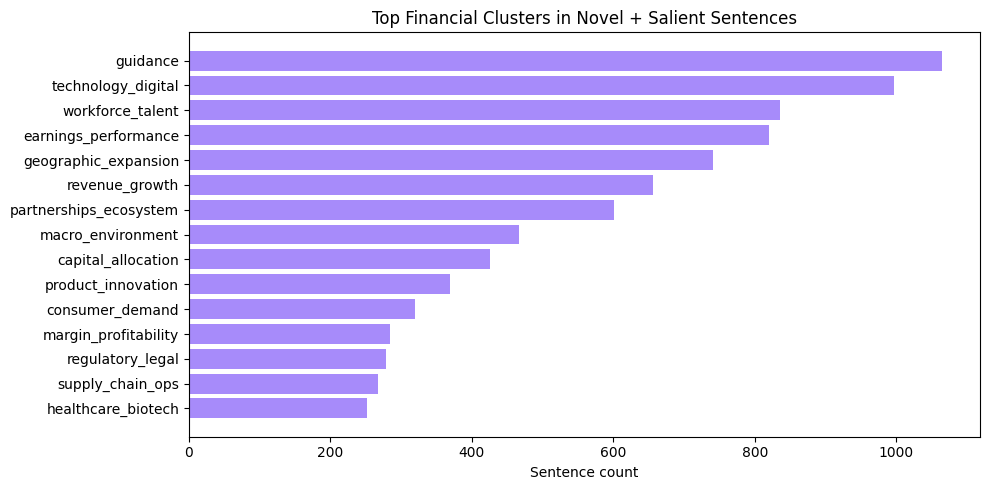


Top 10 clusters in novel sentences:
top_cluster
guidance                  1065
technology_digital         997
workforce_talent           835
earnings_performance       820
geographic_expansion       741
revenue_growth             656
partnerships_ecosystem     601
macro_environment          466
capital_allocation         425
product_innovation         369


In [28]:
# What clusters dominate novel sentences?
cluster_counts = (signal_df["top_cluster"]
                  .value_counts()
                  .head(15))

plt.figure(figsize=(10, 5))
plt.barh(cluster_counts.index[::-1], cluster_counts.values[::-1], color="#a78bfa")
plt.title("Top Financial Clusters in Novel + Salient Sentences", fontsize=12)
plt.xlabel("Sentence count")
plt.tight_layout()
plt.savefig("cluster_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nTop 10 clusters in novel sentences:")
print(cluster_counts.head(10).to_string())


In [29]:
# Example: most novel + salient sentences
print("=== Top 10 Most Novel + Salient Sentences ===\n")
top_examples = (signal_df
                .sort_values(["novelty_score", "salience_score"], ascending=False)
                .head(10))

for _, row in top_examples.iterrows():
    print(f"Ticker : {row['ticker']}  |  Quarter: {row['quarter_str']}")
    print(f"Novelty: {row['novelty_score']:.3f}  |  Salience: {row['salience_score']:.3f}  "
          f"|  Cluster: {row['top_cluster']}")
    print(f"Text   : {row['sentence']}...")
    print()


=== Top 10 Most Novel + Salient Sentences ===

Ticker : AMGN  |  Quarter: 2023Q4
Novelty: 0.910  |  Salience: 2.250  |  Cluster: healthcare_biotech
Text   : With this unique indication for all severities of psoriasis, combined with an established clinical profile, broad payer coverage, a lack of testing required initiation and convenient oral administration....

Ticker : AMZN  |  Quarter: 2023Q4
Novelty: 0.904  |  Salience: 2.990  |  Cluster: technology_digital
Text   : In advertising, we just launched a generative AI image generation tool, where all brands need to do is upload a product photo and description to quickly create unique lifestyle images that will help customers discover products they love....

Ticker : DHR  |  Quarter: 2010Q3
Novelty: 0.902  |  Salience: 1.760  |  Cluster: pricing_strategy
Text   : We recently launched our solo UV green technology solution, which offers our customers a strong value proposition, high ultraviolet output for disaffection with energy efficien

## 5. Step 4 — Macro Adjustment: Cross-Sectional Penalty

If a novel topic fires across ≥40% of firms in the same quarter, it reflects systemic/macro risk — not idiosyncratic firm-level information. We discount such signals.

The penalty is applied at the **cluster × quarter** level: for each quarter, compute the fraction of firms where a given cluster is the dominant novelty cluster. If that fraction exceeds the threshold, reduce the signal weight proportionally.


In [30]:
MACRO_THRESHOLD = 0.40   # 40% of firms in same quarter → systemic, not alpha

# Stable merge keys (avoid Period vs str / NaN buckets breaking the penalty merge)
_n = len(signal_df)
signal_df = signal_df.dropna(subset=["top_cluster"]).copy()
if len(signal_df) < _n:
    print(f"Dropped {_n - len(signal_df):,} rows with missing top_cluster")
signal_df["quarter_str"] = signal_df["quarter_str"].astype(str)
signal_df["top_cluster"] = signal_df["top_cluster"].astype(str)

# Count firms per quarter per cluster
cross_section = (signal_df
                 .groupby(["quarter_str", "top_cluster"])["ticker"]
                 .nunique()
                 .reset_index(name="n_firms"))

# Total firms active per quarter
firms_per_quarter = (signal_df
                     .groupby("quarter_str")["ticker"]
                     .nunique()
                     .reset_index(name="total_firms"))

cross_section = cross_section.merge(firms_per_quarter, on="quarter_str")
cross_section["cross_market_freq"] = (cross_section["n_firms"] /
                                       cross_section["total_firms"])

# Flag systemic topics
cross_section["is_systemic"] = cross_section["cross_market_freq"] >= MACRO_THRESHOLD

# Penalty multiplier: 1.0 if idiosyncratic, scaled down if systemic
cross_section["penalty_mult"] = np.where(
    cross_section["is_systemic"],
    1.0 - cross_section["cross_market_freq"],  # e.g. 60% coverage → 0.4x weight
    1.0
)

print("Systemic topics by quarter (cross-market frequency ≥ 40%):")
systemic = cross_section[cross_section["is_systemic"]].sort_values(
    "cross_market_freq", ascending=False
)
print(systemic[["quarter_str","top_cluster","n_firms","total_firms",
                "cross_market_freq"]].head(20).to_string(index=False))


Systemic topics by quarter (cross-market frequency ≥ 40%):
quarter_str            top_cluster  n_firms  total_firms  cross_market_freq
     2007Q1     capital_allocation        1            1           1.000000
     2007Q3   earnings_performance        1            1           1.000000
     2007Q1        consumer_demand        1            1           1.000000
     2009Q2               guidance        2            2           1.000000
     2008Q3         revenue_growth        2            2           1.000000
     2008Q4         cost_structure        2            2           1.000000
     2008Q1     technology_digital        1            1           1.000000
     2008Q1         revenue_growth        1            1           1.000000
     2008Q1   earnings_performance        1            1           1.000000
     2007Q3          balance_sheet        1            1           1.000000
     2007Q2     technology_digital        1            1           1.000000
     2007Q2         revenue_g

In [32]:
# Merge penalty back into signal_df
# Idempotent: re-running won't leave duplicate suffix columns (penalty_mult_x / _y)
_merge_keys = ["cross_market_freq", "penalty_mult"]
_drop = [
    c for base in _merge_keys
    for c in (base, f"{base}_x", f"{base}_y")
    if c in signal_df.columns
]
if _drop:
    signal_df = signal_df.drop(columns=_drop, errors="ignore")

_cs = cross_section[["quarter_str", "top_cluster", "cross_market_freq", "penalty_mult"]].drop_duplicates(
    subset=["quarter_str", "top_cluster"], keep="last"
)

signal_df = signal_df.merge(
    _cs,
    on=["quarter_str", "top_cluster"],
    how="left",
    validate="many_to_one",
)
signal_df["penalty_mult"] = signal_df["penalty_mult"].fillna(1.0)

# Adjusted novelty signal
signal_df["adjusted_novelty"] = (signal_df["novelty_score"] *
                                  signal_df["salience_score"] *
                                  signal_df["penalty_mult"])

print("Signal score distribution after macro adjustment:")
print(signal_df["adjusted_novelty"].describe().round(4))


Signal score distribution after macro adjustment:
count    9553.0000
mean        1.5002
std         1.0263
min         0.0000
25%         0.8130
50%         1.2458
75%         1.7720
max         8.8043
Name: adjusted_novelty, dtype: float64


## 6. Signal Construction

Aggregate to the **firm-quarter** level. The signal is:

```
adjusted_novelty_score(firm, quarter) = 
    mean(novelty × salience × macro_penalty) over all novel+salient sentences
```

We then merge with the close-to-open return (the overnight market reaction to the earnings call) to evaluate predictive value.


In [19]:
# Aggregate to firm-quarter signal
assert "penalty_mult" in signal_df.columns, (
    "penalty_mult missing — run the macro-adjustment merge cell above first."
)


def _first_mode(s: pd.Series):
    """Mode for aggregation; avoid IndexError when all values are NaN."""
    s = s.dropna()
    if s.empty:
        return np.nan
    m = s.mode()
    return m.iloc[0] if len(m) else np.nan


firm_quarter_signal = (signal_df
    .groupby(["ticker", "quarter_str", "fiscal_year"])
    .agg(
        mean_novelty          = ("novelty_score",   "mean"),
        mean_salience         = ("salience_score",  "mean"),
        mean_adjusted_novelty = ("adjusted_novelty","mean"),
        n_novel_sentences     = ("sentence",        "count"),
        macro_penalty         = ("penalty_mult",    "mean"),
        dominant_cluster      = ("top_cluster",     _first_mode),
        close_to_open_return  = ("close_to_open_return", "first"),
    )
    .reset_index()
)

print(f"Firm-quarter signals: {len(firm_quarter_signal):,}")
print(firm_quarter_signal[["ticker","quarter_str","mean_adjusted_novelty",
                             "close_to_open_return"]].head(10).to_string(index=False))


Firm-quarter signals: 2,398
ticker quarter_str  mean_adjusted_novelty  close_to_open_return
  AAPL      2009Q4               1.897187              0.056568
  AAPL      2010Q1               0.780738              0.014157
  AAPL      2010Q2               1.680869              0.058118
  AAPL      2010Q3               0.919442              0.052404
  AAPL      2010Q4               1.011180             -0.045912
  AAPL      2011Q1               2.585526              0.022604
  AAPL      2011Q2               2.609871              0.036769
  AAPL      2011Q3               1.038052              0.051134
  AAPL      2011Q4               2.667777             -0.049474
  AAPL      2012Q1               2.864507              0.080945


In [20]:
# Rank into quintiles each quarter (cross-sectional signal)
firm_quarter_signal["novelty_quintile"] = (
    firm_quarter_signal
    .groupby("quarter_str")["mean_adjusted_novelty"]
    .transform(lambda x: pd.qcut(x, q=5, labels=[1,2,3,4,5], duplicates="drop")
               if x.nunique() >= 5 else np.nan)
)

# Clean returns
fqs = firm_quarter_signal.dropna(subset=["close_to_open_return","novelty_quintile"]).copy()
fqs["close_to_open_return"] = fqs["close_to_open_return"].clip(-0.15, 0.15)
fqs["novelty_quintile"] = fqs["novelty_quintile"].astype(float)

print(f"Observations with returns + quintile: {len(fqs):,}")
print(fqs.groupby("novelty_quintile")["close_to_open_return"].describe())


Observations with returns + quintile: 2,211
                  count      mean       std   min       25%       50%  \
novelty_quintile                                                        
1.0               466.0  0.004297  0.038449 -0.15 -0.006198  0.001044   
2.0               431.0  0.002192  0.037747 -0.15 -0.008861  0.000341   
3.0               429.0  0.004016  0.040814 -0.15 -0.008714  0.001271   
4.0               430.0  0.000569  0.040215 -0.15 -0.007826  0.000020   
5.0               455.0  0.002164  0.042358 -0.15 -0.010352  0.000130   

                       75%   max  
novelty_quintile                  
1.0               0.009250  0.15  
2.0               0.006910  0.15  
3.0               0.013437  0.15  
4.0               0.007913  0.15  
5.0               0.013644  0.15  


## 7. Backtest: Novelty vs. Post-Earnings Return

The strategy thesis: **high-novelty firms experience a market overreaction** — an initial spike that mean-reverts. We test this by examining close-to-open returns (overnight market reaction) across novelty quintiles.

**Charts:** (1) mean *signed* overnight return by quintile; (2) mean **absolute** overnight return by quintile (typical magnitude of the move, ignoring direction); (3) cumulative long Q1 / short Q5.

The short signal targets **Quintile 5** (highest novelty) — firms discussing something genuinely new that the market overprices on the announcement.


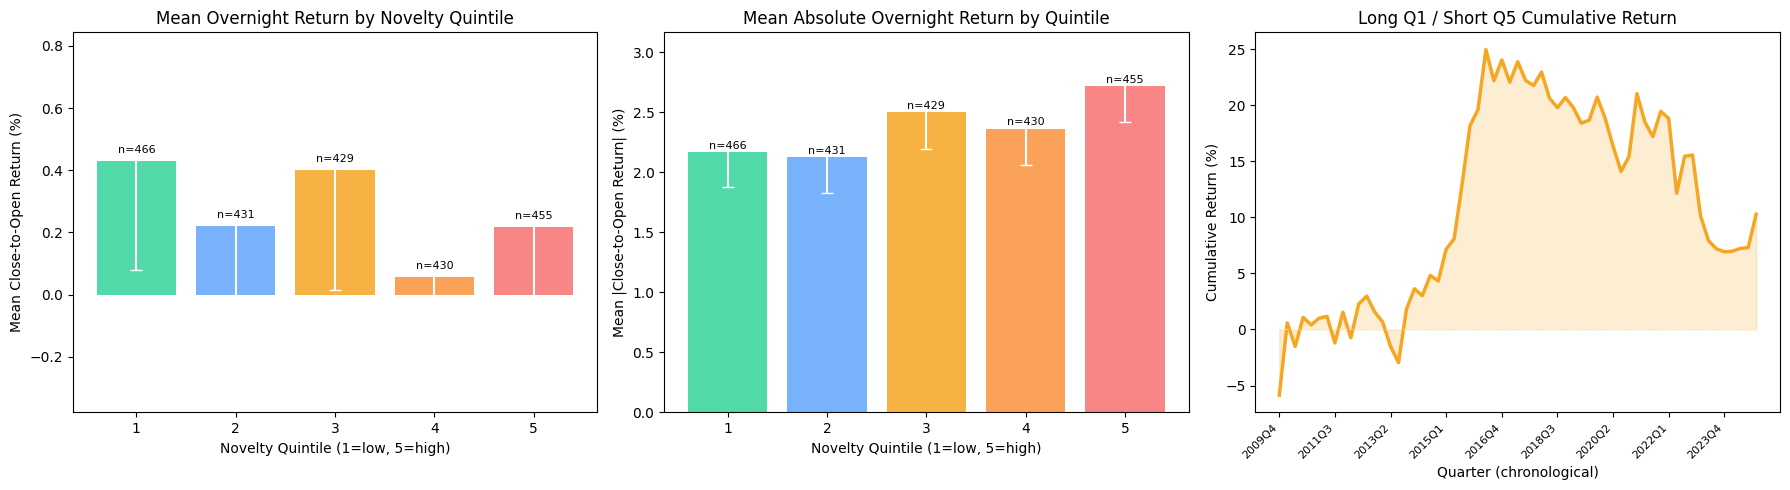

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Mean signed return by quintile ─────────────────────────────────────────
quintile_returns = (fqs.groupby("novelty_quintile")["close_to_open_return"]
                    .agg(["mean","sem","count"])
                    .reset_index())

colors = ["#34d399","#60a5fa","#f5a623","#fb923c","#f87171"]
bars = axes[0].bar(
    quintile_returns["novelty_quintile"],
    quintile_returns["mean"] * 100,
    color=colors,
    alpha=0.85, edgecolor="none"
)
axes[0].errorbar(
    quintile_returns["novelty_quintile"],
    quintile_returns["mean"] * 100,
    yerr=quintile_returns["sem"] * 100 * 1.96,
    fmt="none", color="white", capsize=4, linewidth=1.5
)
axes[0].axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.4)
axes[0].set_xlabel("Novelty Quintile (1=low, 5=high)")
axes[0].set_ylabel("Mean Close-to-Open Return (%)")
axes[0].set_title("Mean Overnight Return by Novelty Quintile")
axes[0].set_xticks([1,2,3,4,5])
for bar, (_, row) in zip(bars, quintile_returns.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f"n={int(row['count'])}",
                 ha="center", va="bottom", fontsize=8)

# ── Mean absolute return by quintile (magnitude of overnight move) ───────
quintile_abs = (
    fqs.groupby("novelty_quintile")["close_to_open_return"]
    .agg(
        mean_abs=lambda s: float(s.abs().mean()),
        sem_abs=lambda s: float(s.abs().sem()) if len(s) > 1 else 0.0,
        count="count",
    )
    .reset_index()
)
# Fix sem for groups with n=1 (sem is NaN)
quintile_abs["sem_abs"] = quintile_abs["sem_abs"].fillna(0.0)

bars_abs = axes[1].bar(
    quintile_abs["novelty_quintile"],
    quintile_abs["mean_abs"] * 100,
    color=colors,
    alpha=0.85,
    edgecolor="none",
)
axes[1].errorbar(
    quintile_abs["novelty_quintile"],
    quintile_abs["mean_abs"] * 100,
    yerr=quintile_abs["sem_abs"] * 100 * 1.96,
    fmt="none",
    color="white",
    capsize=4,
    linewidth=1.5,
)
axes[1].set_xlabel("Novelty Quintile (1=low, 5=high)")
axes[1].set_ylabel("Mean |Close-to-Open Return| (%)")
axes[1].set_title("Mean Absolute Overnight Return by Quintile")
axes[1].set_xticks([1, 2, 3, 4, 5])
for bar, (_, row) in zip(bars_abs, quintile_abs.iterrows()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"n={int(row['count'])}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

# ── Long-short backtest: Q1 long, Q5 short ────────────────────────────────
fqs_sorted = fqs.sort_values("quarter_str")
ls_by_quarter = (fqs_sorted[fqs_sorted["novelty_quintile"].isin([1,5])]
    .groupby(["quarter_str","novelty_quintile"])["close_to_open_return"]
    .mean()
    .unstack()
    .rename(columns={1:"long_Q1", 5:"short_Q5"})
    .dropna()
)
ls_by_quarter["long_short"] = ls_by_quarter["long_Q1"] - ls_by_quarter["short_Q5"]
ls_by_quarter["cumulative_ls"] = (1 + ls_by_quarter["long_short"]).cumprod() - 1

axes[2].plot(range(len(ls_by_quarter)),
             ls_by_quarter["cumulative_ls"] * 100,
             color="#f5a623", linewidth=2.5)
axes[2].fill_between(range(len(ls_by_quarter)),
                      0, ls_by_quarter["cumulative_ls"] * 100,
                      alpha=0.2, color="#f5a623")
axes[2].axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.4)
axes[2].set_xlabel("Quarter (chronological)")
axes[2].set_ylabel("Cumulative Return (%)")
axes[2].set_title("Long Q1 / Short Q5 Cumulative Return")
axes[2].set_xticks(range(0, len(ls_by_quarter), max(1, len(ls_by_quarter)//8)))
axes[2].set_xticklabels(
    ls_by_quarter.index[::max(1, len(ls_by_quarter)//8)],
    rotation=45, ha="right", fontsize=8
)

plt.tight_layout()
plt.savefig("backtest_results.png", dpi=120, bbox_inches="tight")
plt.show()


In [22]:
# Summary statistics
print("=" * 55)
print("STRATEGY PERFORMANCE SUMMARY")
print("=" * 55)

q1 = fqs[fqs["novelty_quintile"] == 1]["close_to_open_return"]
q5 = fqs[fqs["novelty_quintile"] == 5]["close_to_open_return"]
ls = ls_by_quarter["long_short"]

def sharpe(returns, periods_per_year=4):
    """Annualized Sharpe (quarterly observations)."""
    return (returns.mean() / returns.std()) * (periods_per_year ** 0.5)

print(f"{'Metric':<35} {'Q1 (Low Nov.)':>14} {'Q5 (High Nov.)':>15} {'L-S':>10}")
print("-" * 75)
print(f"{'Mean return':<35} {q1.mean()*100:>13.3f}% {q5.mean()*100:>14.3f}% "
      f"{ls.mean()*100:>9.3f}%")
print(f"{'Std dev':<35} {q1.std()*100:>13.3f}% {q5.std()*100:>14.3f}% "
      f"{ls.std()*100:>9.3f}%")
print(f"{'Hit rate (return > 0)':<35} {(q1>0).mean():>14.1%} {(q5>0).mean():>14.1%} "
      f"{(ls>0).mean():>9.1%}")
print(f"{'Annualized Sharpe':<35} {sharpe(q1):>14.3f} {sharpe(q5):>14.3f} "
      f"{sharpe(ls):>9.3f}")
print(f"{'Observations':<35} {len(q1):>14,} {len(q5):>14,} {len(ls):>9,}")
print("=" * 55)


STRATEGY PERFORMANCE SUMMARY
Metric                               Q1 (Low Nov.)  Q5 (High Nov.)        L-S
---------------------------------------------------------------------------
Mean return                                 0.430%          0.216%     0.191%
Std dev                                     3.845%          4.236%     2.500%
Hit rate (return > 0)                        54.3%          50.3%     50.8%
Annualized Sharpe                            0.223          0.102     0.153
Observations                                   466            455        61


## 8. Signal Diagnostics

### 8.1 Novelty by Cluster — which clusters drive the short signal?


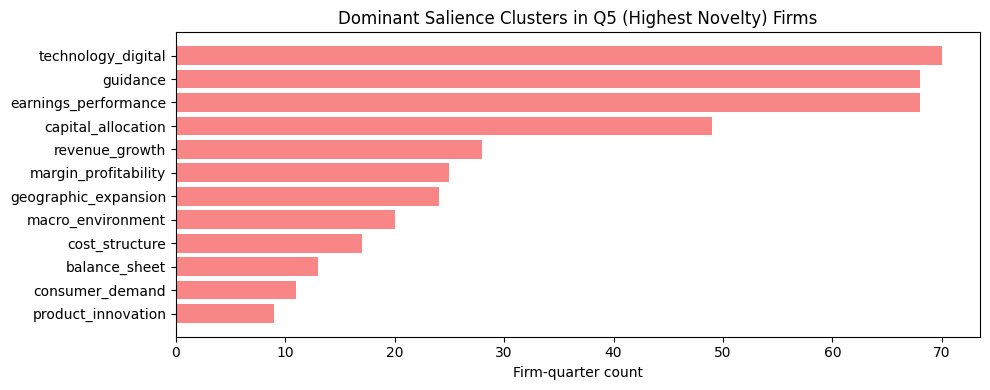

Interpretation: clusters dominating Q5 represent the types of topics
that markets tend to overprice when firms discuss them for the first time.


In [23]:
# Q5 dominant clusters
q5_firms = fqs[fqs["novelty_quintile"] == 5]
q5_clusters = (q5_firms["dominant_cluster"]
               .value_counts()
               .head(12))

plt.figure(figsize=(10, 4))
plt.barh(q5_clusters.index[::-1], q5_clusters.values[::-1], color="#f87171", alpha=0.85)
plt.title("Dominant Salience Clusters in Q5 (Highest Novelty) Firms", fontsize=12)
plt.xlabel("Firm-quarter count")
plt.tight_layout()
plt.savefig("q5_clusters.png", dpi=120, bbox_inches="tight")
plt.show()

print("Interpretation: clusters dominating Q5 represent the types of topics")
print("that markets tend to overprice when firms discuss them for the first time.")


### 8.2 Novelty score vs. return scatter

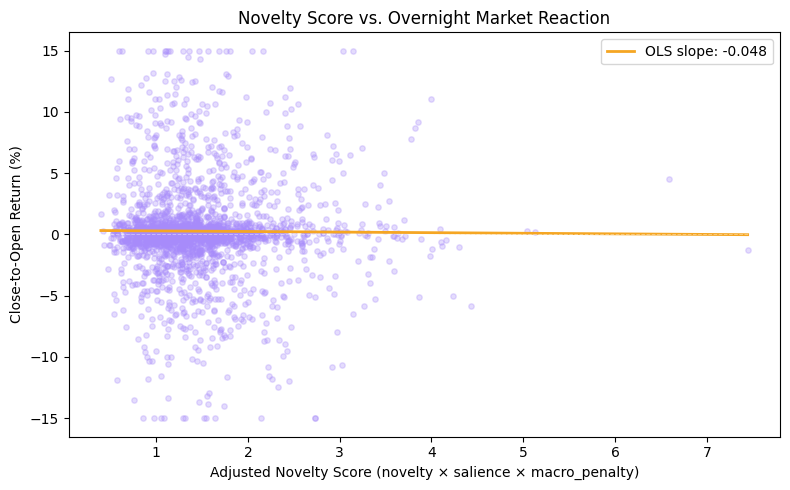

OLS coefficient: -0.0480
Negative slope supports thesis: higher novelty → more overreaction → lower next-day open


In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(
    fqs["mean_adjusted_novelty"],
    fqs["close_to_open_return"] * 100,
    alpha=0.3, s=15, color="#a78bfa"
)

# OLS trend line
from numpy.polynomial import polynomial as P
x = fqs["mean_adjusted_novelty"].values
y = fqs["close_to_open_return"].values * 100
mask = np.isfinite(x) & np.isfinite(y)
coef = np.polyfit(x[mask], y[mask], 1)
xline = np.linspace(x[mask].min(), x[mask].max(), 100)
plt.plot(xline, np.polyval(coef, xline), color="#f5a623", linewidth=2,
         label=f"OLS slope: {coef[0]:.3f}")
plt.axhline(0, color="white", linewidth=0.7, linestyle="--", alpha=0.4)
plt.xlabel("Adjusted Novelty Score (novelty × salience × macro_penalty)")
plt.ylabel("Close-to-Open Return (%)")
plt.title("Novelty Score vs. Overnight Market Reaction")
plt.legend()
plt.tight_layout()
plt.savefig("novelty_vs_return.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"OLS coefficient: {coef[0]:.4f}")
print("Negative slope supports thesis: higher novelty → more overreaction → lower next-day open")


## 9. Example Trade Signals

Pull the top short candidates from the most recent quarter — firms with the highest adjusted novelty scores that passed both the salience and macro filters.


In [25]:
most_recent_q = fqs["quarter_str"].max()
top_shorts = (
    fqs[fqs["quarter_str"] == most_recent_q]
    .nlargest(10, "mean_adjusted_novelty")
    [["ticker","quarter_str","mean_adjusted_novelty","mean_novelty",
      "mean_salience","macro_penalty","dominant_cluster",
      "n_novel_sentences","close_to_open_return"]]
)

print(f"Top Short Candidates — {most_recent_q}")
print(top_shorts.to_string(index=False))


Top Short Candidates — 2024Q4
ticker quarter_str  mean_adjusted_novelty  mean_novelty  mean_salience  macro_penalty     dominant_cluster  n_novel_sentences  close_to_open_return
   JPM      2024Q4               4.089176      0.624302       6.550000            1.0    macro_environment                  1              0.004094
  AAPL      2024Q4               3.201838      0.617989       5.155000            1.0   esg_sustainability                  2             -0.021889
  NVDA      2024Q4               2.788532      0.634540       4.331600            1.0   technology_digital                  5              0.023717
  SPGI      2024Q4               2.662421      0.622646       4.273333            1.0   capital_allocation                  3              0.008881
  ORCL      2024Q4               2.401282      0.622539       3.864000            1.0   technology_digital                  6             -0.089210
  MSFT      2024Q4               2.357038      0.631495       3.795200            

In [26]:
# Show the specific novel sentences for the top signal
top_ticker = top_shorts.iloc[0]["ticker"]
top_q      = top_shorts.iloc[0]["quarter_str"]

top_sents = (signal_df[
    (signal_df["ticker"] == top_ticker) &
    (signal_df["quarter_str"] == top_q)
]
.nlargest(5, "adjusted_novelty")
[["sentence","novelty_score","salience_score","top_cluster","adjusted_novelty"]])

print(f"\n=== Top novel sentences: {top_ticker} {top_q} ===\n")
for _, row in top_sents.iterrows():
    print(f"Cluster  : {row['top_cluster']}")
    print(f"Novelty  : {row['novelty_score']:.3f}  |  Salience: {row['salience_score']:.3f}  "
          f"|  Adjusted: {row['adjusted_novelty']:.4f}")
    print(f"Sentence : {row['sentence'][:200]}")
    print()



=== Top novel sentences: JPM 2024Q4 ===

Cluster  : macro_environment
Novelty  : 0.624  |  Salience: 6.550  |  Adjusted: 4.0892
Sentence : In light of the positive momentum throughout the year, we're optimistic about our pipeline, but the M&A regulatory environment and geopolitical situation are continued sources of uncertainty.



## 10. Discussion & Limitations

### What this implements from the strategy paper
| Step | Paper | Implementation |
|------|-------|----------------|
| Baseline Build | Per-firm TF-IDF vocabulary profile | ✅ Rolling TF-IDF per firm-quarter |
| Semantic Check | Sentence embeddings + cosine distance | ✅ `all-MiniLM-L6-v2` + centroid distance |
| Intent Verify | LLM binary classifier (YES/NO) | ✅ Salience dictionary (26 clusters, weighted) |
| Macro Adjust | Cross-sectional frequency discount | ✅ Cluster × quarter firm-frequency penalty |

### Why `all-MiniLM-L6-v2` and not FinBERT for embeddings
FinBERT is fine-tuned on financial text for **sentiment classification** (positive/negative/neutral). Its internal representations encode sentiment polarity — the cosine distance between two FinBERT embeddings measures how different their *sentiment* is, not how *semantically novel* one sentence is relative to historical context. Using FinBERT embeddings for novelty detection would flag positive-vs-negative sentence pairs as "novel" even if they discuss identical topics, and would fail to flag genuinely new vocabulary.

`all-MiniLM-L6-v2` is trained on paraphrase and semantic textual similarity tasks — its embedding space preserves meaning such that cosine distance is a valid measure of semantic novelty.

### Limitations & extensions
- **Look-ahead bias:** Ensure baseline only includes transcripts strictly before the event quarter (✅ implemented)
- **Model staleness:** A firm that legitimately pivots will generate persistent false signals — re-weight baseline with recency decay
- **LLM intent filter:** The salience dictionary is a strong proxy but cannot perform the nuanced binary YES/NO classification the paper envisions — a Claude/GPT call on the top-5 novel sentences per firm would add precision
- **Mean reversion horizon T:** This analysis uses the overnight close-to-open return; the paper implies holding for T days — extending to 5/10/20-day cumulative returns is a natural next step
- **Short execution:** Entry timing (after spike confirmation), borrowing costs, and bid-ask spread are not modeled here
